In [1]:
import numpy as np
from ase.build import bulk
from mace.calculators import MACECalculator
import pandas as pd
from ase.optimize import BFGS
from ase.filters import UnitCellFilter
from oncapintada.subregular_model import BinaryAlloy
import matplotlib.pyplot as plt


/Users/leseixas/miniconda3/envs/onca/lib/python3.11/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
                                           
          ▄▖          ▘  ▗    ▌            
          ▌▌▛▌▛▘▀▌▄▖▛▌▌▛▌▜▘▀▌▛▌▀▌          
          ▙▌▌▌▙▖█▌  ▙▌▌▌▌▐▖█▌▙▌█▌          
                    ▌                      
                                           
    version: 26.4.22                 
    developed by: Leandro Seixas Rocha       
    homepage: https://github.com/seixas-research/oncapintada
                                                  
------------------------------------------------------------
                                                  
System:
├── architecture: arm64
├── platform: Darwin
├── user: leseixas
├── hostname: safira
├── cwd: /Users/leseixas/Library/CloudStorage/Dropbox/Repositories/seixas-research/oncapintada/examples
└── PID: 34465
                                               
Python:
├── version: 3.11.15 | packaged by conda-forge | (main, M

In [2]:
# ff = MACE-matpes-pbe-omat-ft.model | MACE-matpes-r2scan-omat-ft.model | mace-omat-0-medium.model
ff = 'MACE-matpes-pbe-omat-ft.model'
calc = MACECalculator(model_paths=f"/Users/leseixas/.local/mace/{ff}",
                      device='cpu',
                      default_dtype='float32') 

In [3]:
elements = ["Au", "Pt"]
energy_matrix = np.zeros((len(elements), len(elements)))
for j, element in enumerate(elements):
    atoms = bulk(element, cubic=True)
    atoms.calc = calc
    opt = BFGS(UnitCellFilter(atoms), logfile=None)
    opt.run(fmax=0.01)
    energy = atoms.get_potential_energy()
    print(f"{element}: {energy:.6f} eV")

    # SUPERCELL
    supercell = atoms.repeat((2, 2, 2)).copy()
    supercell.calc = calc
    opt_supercell = BFGS(UnitCellFilter(supercell), logfile=None)
    opt_supercell.run(fmax=0.01)
    energy_supercell = supercell.get_potential_energy()
    energy_matrix[j, j] = energy_supercell
    print(f"{element} supercell: {energy_supercell:.6f} eV")
    print(f"Number of atoms in supercell: {len(supercell)}")

    # IMPURITIES
    for i, impurity in enumerate(elements):
        if impurity != element:
            impurity_atoms = supercell.copy()
            impurity_atoms[0].symbol = impurity
            impurity_atoms.calc = calc
            opt_impurity = BFGS(UnitCellFilter(impurity_atoms), logfile=None)
            opt_impurity.run(fmax=0.01)
            energy_impurity = impurity_atoms.get_potential_energy()
            print(f"{element} with {impurity} impurity: {energy_impurity:.6f} eV")
            # print(f"Number of atoms in impurity supercell: {len(impurity_atoms)}")
            energy_matrix[i, j] = energy_impurity



Au: -12.895026 eV
Au supercell: -103.160202 eV
Number of atoms in supercell: 32
Au with Pt impurity: -105.836197 eV
Pt: -24.377337 eV
Pt supercell: -195.018661 eV
Number of atoms in supercell: 32
Pt with Au impurity: -191.818268 eV


In [4]:
energy_matrix

array([[-103.16020203, -191.81826782],
       [-105.8361969 , -195.0186615 ]])

In [ ]:
x0 = 1/32
M = np.zeros((2, 2))
M[0,1] = energy_matrix[0, 1] - ((1-x0)* energy_matrix[1, 1] + x0*energy_matrix[0, 0])
M[1,0] = energy_matrix[1, 0] - ((1-x0)* energy_matrix[0, 0] + x0*energy_matrix[1, 1])
k = 96.485
print(M*k)

[[0.         0.32981682]
 [0.19458199 0.        ]]


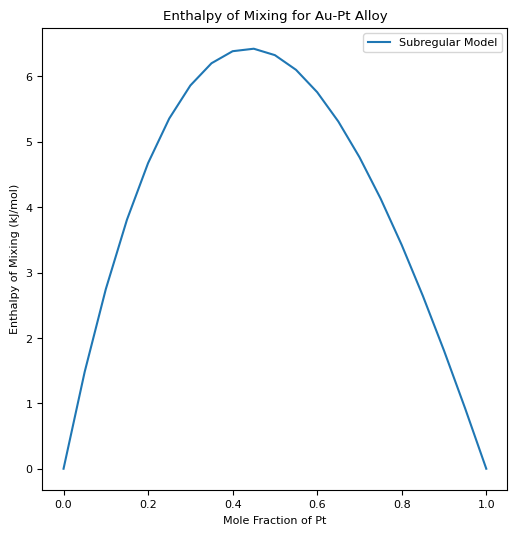

In [7]:
plt.figure(figsize=(6,6))

x = np.linspace(0, 1, 21)
h_mix = (M[0, 1] * (1-x) + M[1, 0] * x) * x * (1-x)
plt.plot(x, h_mix*k, label='Subregular Model')
plt.xlabel('Mole Fraction of Pt')
plt.ylabel('Enthalpy of Mixing (kJ/mol)')
plt.title('Enthalpy of Mixing for Au-Pt Alloy')
plt.legend()
# plt.grid()
plt.show()

In [8]:
model = BinaryAlloy(energy_matrix=energy_matrix, dilution=1/32)

In [9]:
model.Mij()

array([[0.        , 0.32981682],
       [0.19458199, 0.        ]])

In [10]:
enthalpy = model.enthalpy_of_mixing(x)

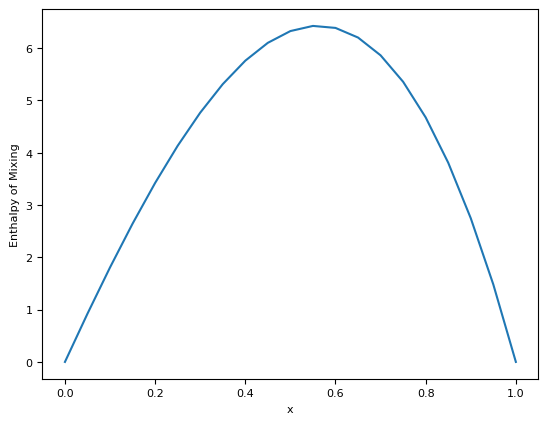

In [12]:
plt.plot(x, enthalpy)
plt.xlabel('x')
plt.ylabel('Enthalpy of Mixing')
plt.show()